# Stage 3: Structural Analysis - Step-by-Step Visualization

Notebook này giúp bạn hiểu trực quan từng bước của Stage 3 Extraction trong pipeline Geo-SLM.

## Pipeline Overview

```
Input Image → Preprocessing → Skeletonization → Vectorization
                                    ↓
                              OCR Extraction
                                    ↓
                           Element Detection
                                    ↓
                          Geometric Mapping
                                    ↓
                            Classification
                                    ↓
                              Raw Metadata
```

In [1]:
# Setup: Import libraries
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib import patches
from PIL import Image

# Set matplotlib defaults
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Create Sample Chart Image

Đầu tiên, tạo một chart image mẫu để demo pipeline.

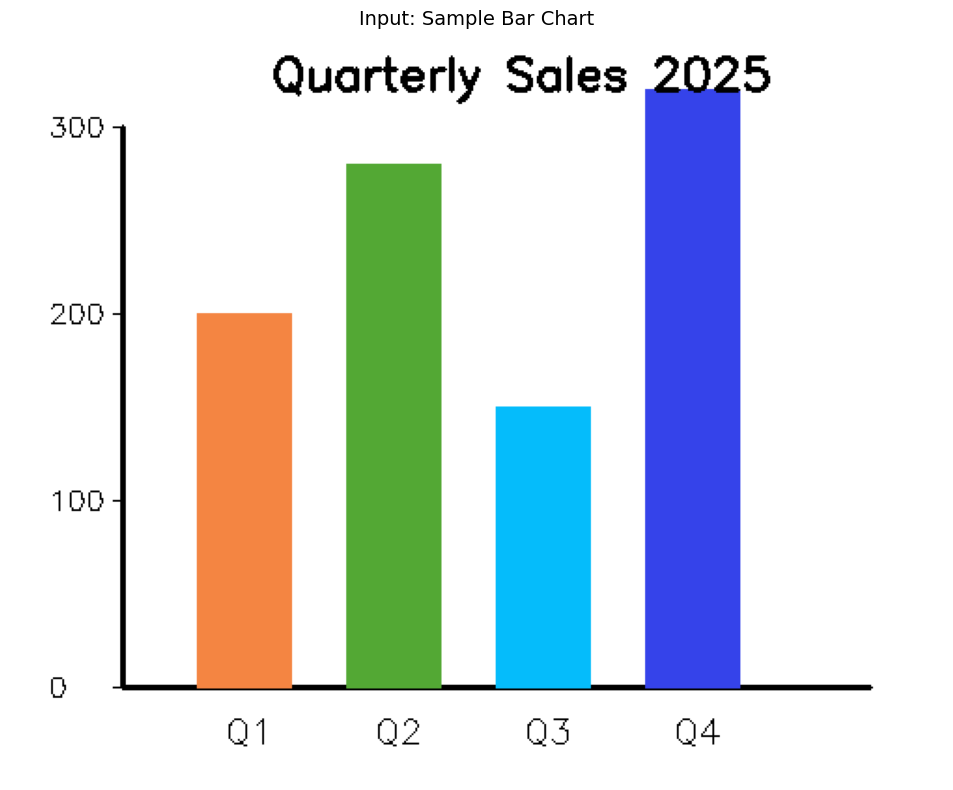

Image shape: (400, 500, 3)


In [2]:
def create_sample_bar_chart():
    """Create a sample bar chart for demonstration."""
    # Create white background
    img = np.ones((400, 500, 3), dtype=np.uint8) * 255
    
    # Draw axes
    cv2.line(img, (60, 50), (60, 350), (0, 0, 0), 2)  # Y-axis
    cv2.line(img, (60, 350), (460, 350), (0, 0, 0), 2)  # X-axis
    
    # Draw bars with different heights
    bar_data = [
        (100, 200, (66, 133, 244)),   # Blue - height 200
        (180, 280, (52, 168, 83)),    # Green - height 280  
        (260, 150, (251, 188, 5)),    # Yellow - height 150
        (340, 320, (234, 67, 53)),    # Red - height 320
    ]
    
    for x, height, color in bar_data:
        cv2.rectangle(img, (x, 350 - height), (x + 50, 350), color, -1)
    
    # Add title
    cv2.putText(img, "Quarterly Sales 2025", (140, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)
    
    # Add X-axis labels
    labels = ["Q1", "Q2", "Q3", "Q4"]
    x_positions = [115, 195, 275, 355]
    for label, x in zip(labels, x_positions):
        cv2.putText(img, label, (x, 380), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)
    
    # Add Y-axis labels
    y_labels = [("0", 350), ("100", 250), ("200", 150), ("300", 50)]
    for label, y in y_labels:
        cv2.putText(img, label, (20, y + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
        cv2.line(img, (55, y), (60, y), (0, 0, 0), 1)  # Tick marks
    
    return img

# Create and display sample chart
sample_chart = create_sample_bar_chart()

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(sample_chart, cv2.COLOR_BGR2RGB))
plt.title("Input: Sample Bar Chart", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Image shape: {sample_chart.shape}")

---
## 2. Step 1: Preprocessing (Negative Transform)

**Mục đích:** Chuyển đổi ảnh để tăng cường contrast cho các đường nét structural.

**Các bước:**
1. Grayscale conversion
2. Denoising (Gaussian blur)
3. Negative transform (đảo màu)
4. Morphological operations
5. Adaptive thresholding

In [3]:
from core_engine.stages.s3_extraction.preprocessor import ImagePreprocessor, PreprocessConfig

# Initialize preprocessor
preprocess_config = PreprocessConfig(
    apply_denoise=True,
    apply_negative=True,
    apply_morphology=True,
)
preprocessor = ImagePreprocessor(preprocess_config)

# Process the image
preprocess_result = preprocessor.process(sample_chart, chart_id="demo_001")

print("Preprocessing Result:")
print(f"  - Steps applied: {preprocess_result.steps_applied}")
print(f"  - Binary image shape: {preprocess_result.binary_image.shape}")

Preprocessing Result:


AttributeError: 'PreprocessResult' object has no attribute 'steps_applied'

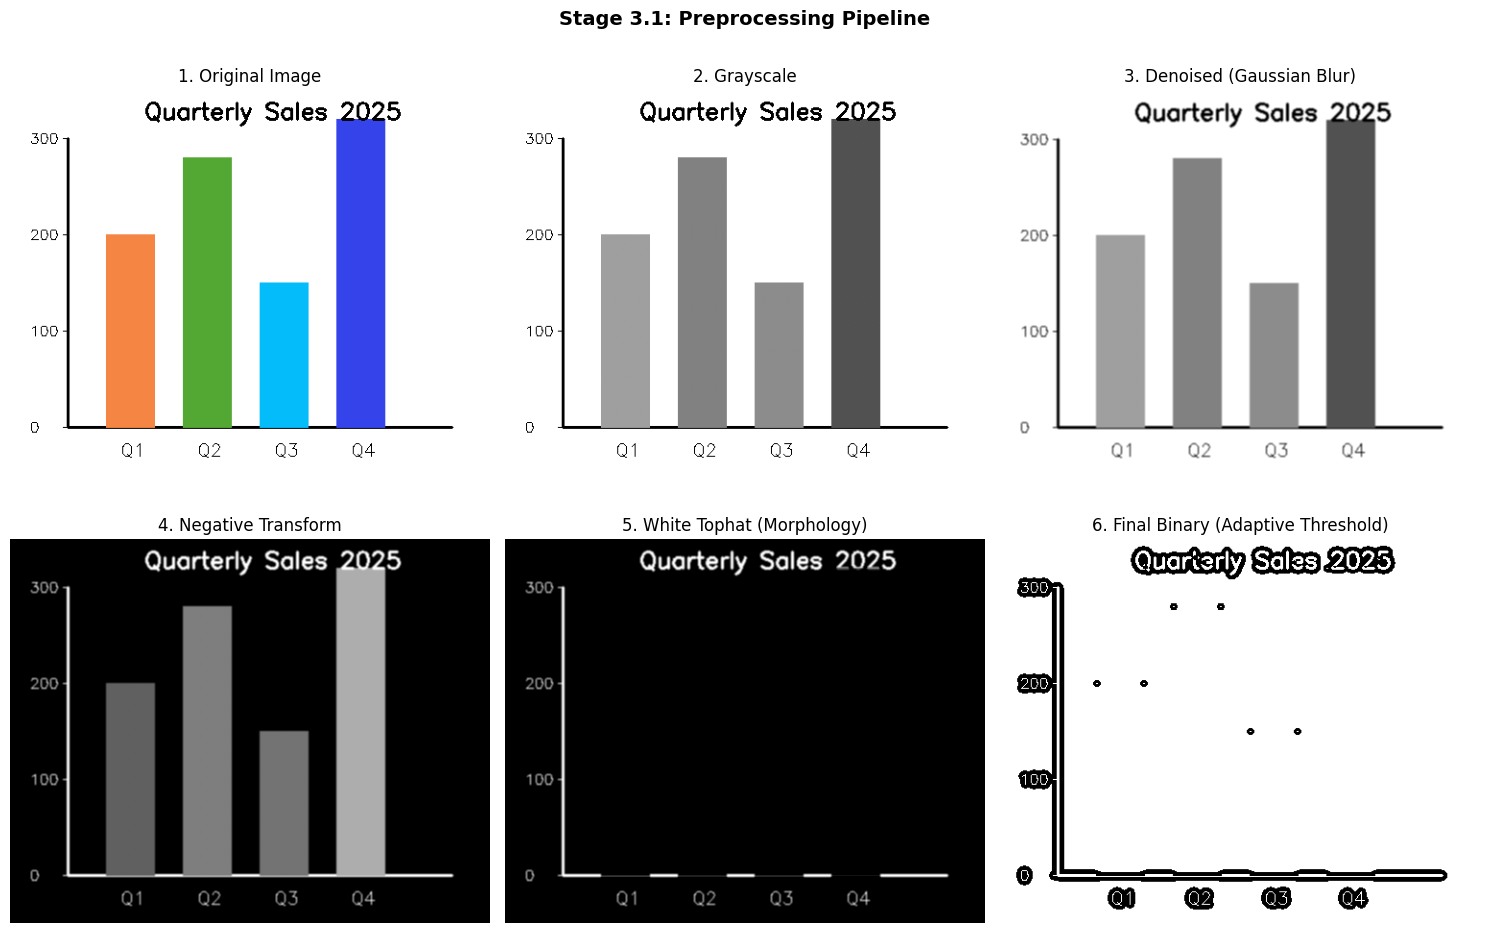

In [4]:
# Visualize preprocessing steps
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original
axes[0, 0].imshow(cv2.cvtColor(sample_chart, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("1. Original Image", fontsize=12)
axes[0, 0].axis('off')

# Grayscale
gray = cv2.cvtColor(sample_chart, cv2.COLOR_BGR2GRAY)
axes[0, 1].imshow(gray, cmap='gray')
axes[0, 1].set_title("2. Grayscale", fontsize=12)
axes[0, 1].axis('off')

# Denoised
denoised = cv2.GaussianBlur(gray, (3, 3), 0)
axes[0, 2].imshow(denoised, cmap='gray')
axes[0, 2].set_title("3. Denoised (Gaussian Blur)", fontsize=12)
axes[0, 2].axis('off')

# Negative transform
negative = 255 - denoised
axes[1, 0].imshow(negative, cmap='gray')
axes[1, 0].set_title("4. Negative Transform", fontsize=12)
axes[1, 0].axis('off')

# White tophat (morphology)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
tophat = cv2.morphologyEx(negative, cv2.MORPH_TOPHAT, kernel)
axes[1, 1].imshow(tophat, cmap='gray')
axes[1, 1].set_title("5. White Tophat (Morphology)", fontsize=12)
axes[1, 1].axis('off')

# Final binary from preprocessor
axes[1, 2].imshow(preprocess_result.binary_image, cmap='gray')
axes[1, 2].set_title("6. Final Binary (Adaptive Threshold)", fontsize=12)
axes[1, 2].axis('off')

plt.suptitle("Stage 3.1: Preprocessing Pipeline", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Step 2: Skeletonization

**Mục đích:** Biến đổi các vùng binary thành đường xương sống (skeleton) để trích xuất topology.

**Thuật toán:** Lee's Algorithm (topology-preserving thinning)

**Kết quả:**
- Skeleton image (1-pixel wide lines)
- Keypoints (endpoints, junctions)
- Distance map (stroke width estimation)

In [5]:
from core_engine.stages.s3_extraction.skeletonizer import Skeletonizer, SkeletonConfig

# Initialize skeletonizer
skeleton_config = SkeletonConfig(
    remove_spurs=True,
    spur_length=5,
)
skeletonizer = Skeletonizer(skeleton_config)

# Process binary image
skeleton_result = skeletonizer.process(
    preprocess_result.binary_image, 
    chart_id="demo_001"
)

print("Skeletonization Result:")
print(f"  - Keypoints found: {skeleton_result.keypoint_count}")
print(f"  - Skeleton pixels: {np.sum(skeleton_result.skeleton > 0)}")

Skeletonization Result:


AttributeError: 'SkeletonResult' object has no attribute 'keypoint_count'

AttributeError: 'SkeletonResult' object has no attribute 'keypoint_count'

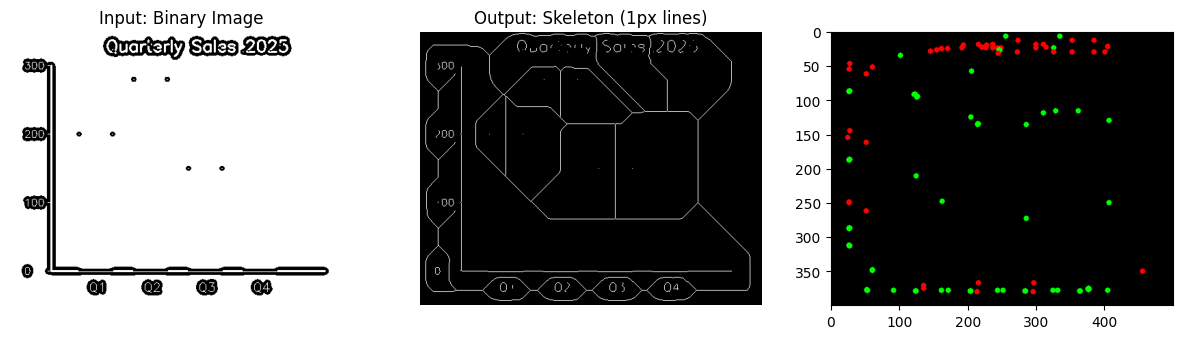

In [6]:
# Visualize skeletonization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Binary input
axes[0].imshow(preprocess_result.binary_image, cmap='gray')
axes[0].set_title("Input: Binary Image", fontsize=12)
axes[0].axis('off')

# Skeleton
axes[1].imshow(skeleton_result.skeleton, cmap='gray')
axes[1].set_title("Output: Skeleton (1px lines)", fontsize=12)
axes[1].axis('off')

# Skeleton with keypoints overlay
skeleton_rgb = cv2.cvtColor(
    (skeleton_result.skeleton * 255).astype(np.uint8), 
    cv2.COLOR_GRAY2RGB
)

# Draw keypoints
for kp in skeleton_result.keypoints:
    x, y = int(kp.point.x), int(kp.point.y)
    color = (255, 0, 0) if kp.point_type.value == 'endpoint' else (0, 255, 0)
    cv2.circle(skeleton_rgb, (x, y), 4, color, -1)

axes[2].imshow(skeleton_rgb)
axes[2].set_title(f"Keypoints: {skeleton_result.keypoint_count}\n(Red=Endpoint, Green=Junction)", fontsize=12)
axes[2].axis('off')

plt.suptitle("Stage 3.2: Skeletonization (Lee's Algorithm)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Step 3: Vectorization (RDP Algorithm)

**Mục đích:** Chuyển skeleton thành các polylines (vectors) với số điểm tối thiểu.

**Thuật toán:** Ramer-Douglas-Peucker (RDP) simplification

**Kết quả:**
- Polylines (list of points)
- Line style detection (solid, dashed)
- Stroke width estimation

In [7]:
from core_engine.stages.s3_extraction.vectorizer import Vectorizer, VectorizeConfig

# First, trace paths from skeleton
traced_paths = skeletonizer.trace_paths(
    skeleton_result.skeleton,
    min_length=10
)

print(f"Traced {len(traced_paths)} paths from skeleton")

# Initialize vectorizer
vectorize_config = VectorizeConfig(
    epsilon=2.0,  # RDP simplification tolerance
    min_segment_length=5,
)
vectorizer = Vectorizer(vectorize_config)

# Vectorize paths
vectorize_result = vectorizer.process(traced_paths, chart_id="demo_001")

print(f"\nVectorization Result:")
print(f"  - Polylines created: {len(vectorize_result.polylines)}")
print(f"  - Total simplification: {vectorize_result.simplification_ratio:.1%}")

TypeError: Skeletonizer.trace_paths() got an unexpected keyword argument 'min_length'

NameError: name 'traced_paths' is not defined

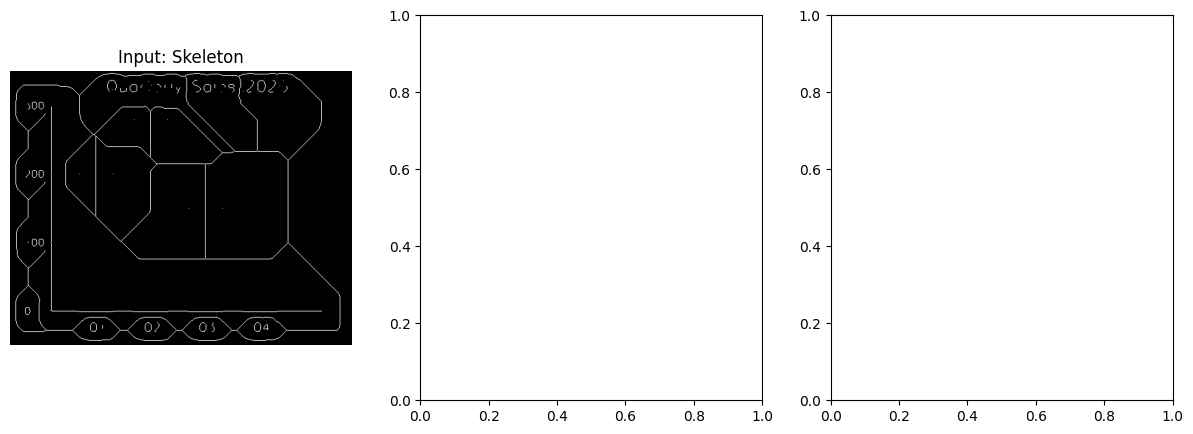

In [8]:
# Visualize vectorization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Skeleton
axes[0].imshow(skeleton_result.skeleton, cmap='gray')
axes[0].set_title("Input: Skeleton", fontsize=12)
axes[0].axis('off')

# Traced paths (raw)
path_img = np.zeros_like(sample_chart)
colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(traced_paths))))
for i, path in enumerate(traced_paths[:10]):  # Show first 10
    color = tuple(int(c * 255) for c in colors[i][:3])
    for j in range(len(path) - 1):
        pt1 = (int(path[j][0]), int(path[j][1]))
        pt2 = (int(path[j+1][0]), int(path[j+1][1]))
        cv2.line(path_img, pt1, pt2, color, 2)

axes[1].imshow(path_img)
axes[1].set_title(f"Traced Paths: {len(traced_paths)} (raw)", fontsize=12)
axes[1].axis('off')

# Vectorized polylines (simplified)
vector_img = np.zeros_like(sample_chart)
for i, polyline in enumerate(vectorize_result.polylines[:10]):
    color = tuple(int(c * 255) for c in colors[i][:3])
    points = [(int(p.x), int(p.y)) for p in polyline.points]
    for j in range(len(points) - 1):
        cv2.line(vector_img, points[j], points[j+1], color, 2)
    # Draw vertices
    for pt in points:
        cv2.circle(vector_img, pt, 3, (255, 255, 255), -1)

axes[2].imshow(vector_img)
axes[2].set_title(f"Vectorized: {len(vectorize_result.polylines)} polylines\n(White dots = vertices)", fontsize=12)
axes[2].axis('off')

plt.suptitle("Stage 3.3: Vectorization (RDP Simplification)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Step 4: OCR Text Extraction

**Mục đích:** Trích xuất tất cả text từ chart image và phân loại vai trò.

**Engine:** PaddleOCR

**Text Roles:**
- `title`: Tiêu đề chart
- `xlabel`: Nhãn trục X
- `ylabel`: Nhãn trục Y
- `legend`: Chú thích
- `value`: Giá trị trên chart

In [9]:
from core_engine.stages.s3_extraction.ocr_engine import OCREngine, OCRConfig

# Initialize OCR engine
ocr_config = OCRConfig(
    languages=["en"],
    detect_orientation=False,
)
ocr_engine = OCREngine(ocr_config)

# Extract text
ocr_result = ocr_engine.extract(sample_chart, chart_id="demo_001")

print(f"OCR Result: Found {len(ocr_result.texts)} text elements\n")
for i, text in enumerate(ocr_result.texts):
    print(f"  [{i+1}] '{text.text}' (conf: {text.confidence:.2f}, role: {text.role})")

AttributeError: 'OCREngine' object has no attribute 'extract'

NameError: name 'ocr_result' is not defined

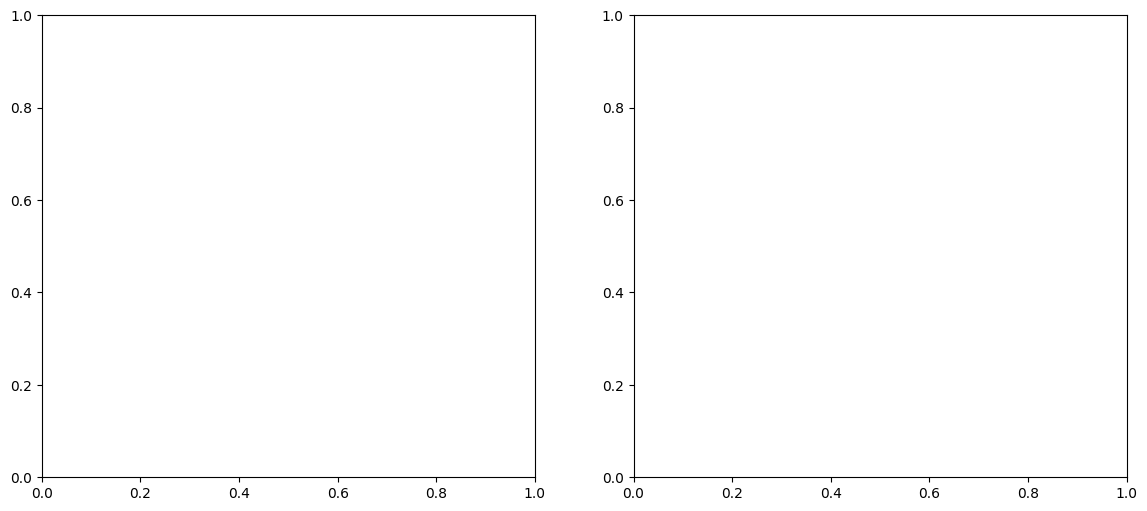

In [10]:
# Visualize OCR results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original with bounding boxes
ocr_viz = sample_chart.copy()

role_colors = {
    'title': (255, 0, 0),      # Red
    'xlabel': (0, 255, 0),     # Green
    'ylabel': (0, 0, 255),     # Blue
    'legend': (255, 165, 0),   # Orange
    'value': (128, 0, 128),    # Purple
    None: (128, 128, 128),     # Gray for unknown
}

for text in ocr_result.texts:
    bbox = text.bbox
    color = role_colors.get(text.role, (128, 128, 128))
    cv2.rectangle(ocr_viz, 
                  (bbox.x_min, bbox.y_min), 
                  (bbox.x_max, bbox.y_max), 
                  color, 2)

axes[0].imshow(cv2.cvtColor(ocr_viz, cv2.COLOR_BGR2RGB))
axes[0].set_title("OCR Bounding Boxes", fontsize=12)
axes[0].axis('off')

# Legend
legend_elements = [
    patches.Patch(facecolor='red', label='Title'),
    patches.Patch(facecolor='green', label='X-Label'),
    patches.Patch(facecolor='blue', label='Y-Label'),
    patches.Patch(facecolor='orange', label='Legend'),
    patches.Patch(facecolor='purple', label='Value'),
]
axes[0].legend(handles=legend_elements, loc='upper right')

# Text list
axes[1].axis('off')
text_content = "Extracted Text Elements:\n" + "="*40 + "\n\n"
for i, text in enumerate(ocr_result.texts):
    role_str = text.role or "unknown"
    text_content += f"{i+1}. '{text.text}'\n"
    text_content += f"   Role: {role_str}, Confidence: {text.confidence:.2f}\n"
    text_content += f"   Position: ({text.bbox.x_min}, {text.bbox.y_min})\n\n"

axes[1].text(0.05, 0.95, text_content, transform=axes[1].transAxes,
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1].set_title("Extracted Text Details", fontsize=12)

plt.suptitle("Stage 3.4: OCR Text Extraction (PaddleOCR)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Step 5: Element Detection

**Mục đích:** Phát hiện các phần tử rời rạc trong chart.

**Loại phần tử:**
- **Bars**: Cột trong bar chart
- **Markers**: Điểm trong scatter/line chart
- **Slices**: Phần trong pie chart

In [11]:
from core_engine.stages.s3_extraction.element_detector import ElementDetector, ElementDetectorConfig

# Initialize detector
detector_config = ElementDetectorConfig(
    detect_bars=True,
    detect_markers=True,
    detect_pie_slices=True,
    min_bar_area=100,
)
element_detector = ElementDetector(detector_config)

# Detect elements
detection_result = element_detector.detect(
    preprocess_result.binary_image,
    sample_chart  # Color image for color extraction
)

print(f"Element Detection Result:")
print(f"  - Bars detected: {len(detection_result.bars)}")
print(f"  - Markers detected: {len(detection_result.markers)}")
print(f"  - Pie slices detected: {len(detection_result.slices)}")
print(f"  - Contours analyzed: {detection_result.contours_analyzed}")

Element Detection Result:
  - Bars detected: 1
  - Markers detected: 3
  - Pie slices detected: 0
  - Contours analyzed: 1


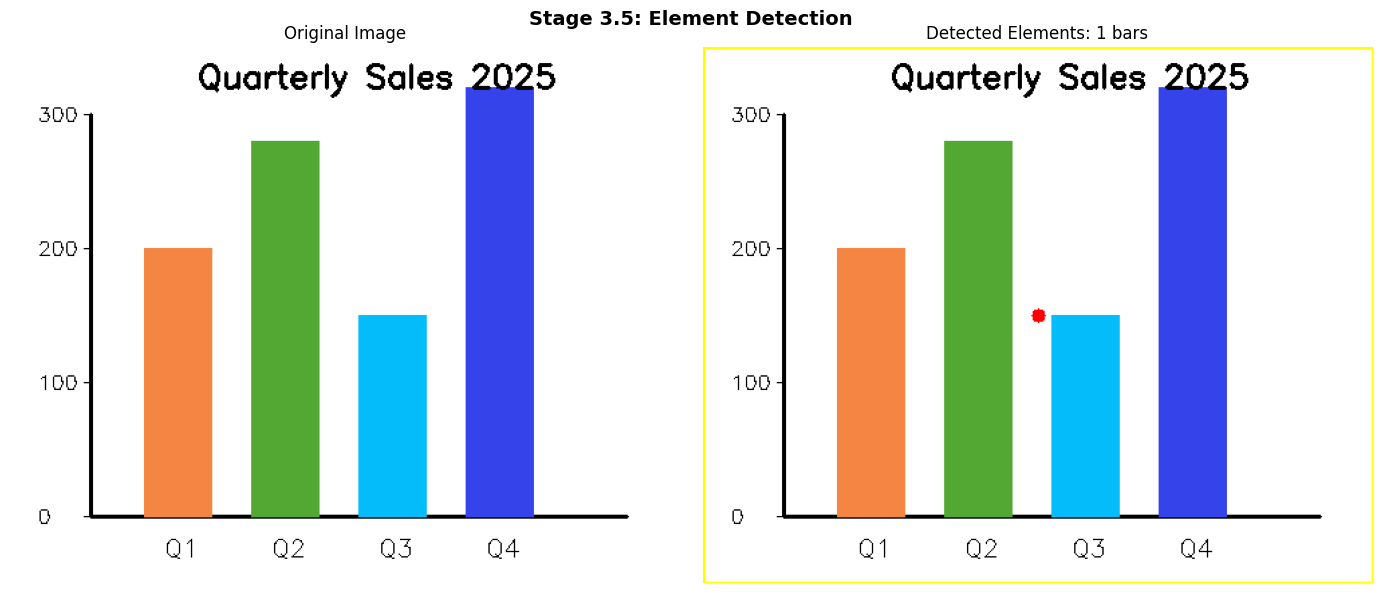


Detected Bar Details:
------------------------------------------------------------
Bar 1:
  Position: (0, 0) to (500, 400)
  Size: 500 x 400 pixels
  Color: RGB(210, 219, 223)



In [12]:
# Visualize detected elements
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original
axes[0].imshow(cv2.cvtColor(sample_chart, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image", fontsize=12)
axes[0].axis('off')

# Detected bars
detected_viz = sample_chart.copy()

for i, bar in enumerate(detection_result.bars):
    # Draw bounding box
    cv2.rectangle(detected_viz,
                  (int(bar.x_min), int(bar.y_min)),
                  (int(bar.x_max), int(bar.y_max)),
                  (0, 255, 255), 2)  # Cyan border
    
    # Draw center
    cx, cy = int(bar.center.x), int(bar.center.y)
    cv2.circle(detected_viz, (cx, cy), 5, (0, 0, 255), -1)
    
    # Label
    cv2.putText(detected_viz, f"Bar {i+1}", 
                (int(bar.x_min), int(bar.y_min) - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)

axes[1].imshow(cv2.cvtColor(detected_viz, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Detected Elements: {len(detection_result.bars)} bars", fontsize=12)
axes[1].axis('off')

plt.suptitle("Stage 3.5: Element Detection", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print bar details
print("\nDetected Bar Details:")
print("-" * 60)
for i, bar in enumerate(detection_result.bars):
    print(f"Bar {i+1}:")
    print(f"  Position: ({bar.x_min:.0f}, {bar.y_min:.0f}) to ({bar.x_max:.0f}, {bar.y_max:.0f})")
    print(f"  Size: {bar.width:.0f} x {bar.height:.0f} pixels")
    if bar.color:
        print(f"  Color: RGB({bar.color.r}, {bar.color.g}, {bar.color.b})")
    print()

---
## 7. Step 6: Geometric Mapping

**Mục đích:** Chuyển đổi pixel coordinates thành data values thực.

**Phương pháp:**
1. Calibrate axes từ OCR tick labels
2. Linear regression để tìm scale
3. Map pixel positions → actual values

In [13]:
from core_engine.stages.s3_extraction.geometric_mapper import GeometricMapper, MapperConfig

# Initialize mapper
mapper_config = MapperConfig(
    min_calibration_points=2,
    auto_detect_scale=True,
)
mapper = GeometricMapper(mapper_config)

# Create calibration data from Y-axis labels
# Format: (pixel_y, value)
y_calibration = [
    (350.0, 0.0),    # "0" at pixel 350
    (250.0, 100.0),  # "100" at pixel 250
    (150.0, 200.0),  # "200" at pixel 150
    (50.0, 300.0),   # "300" at pixel 50
]

# Calibrate Y-axis
y_calibration_result = mapper.calibrate_y_axis(y_calibration)

print("Y-Axis Calibration:")
print(f"  - R-squared: {y_calibration_result.r_squared:.4f}")
print(f"  - Scale: slope={y_calibration_result.scale.slope:.4f}, intercept={y_calibration_result.scale.intercept:.4f}")
print(f"  - Type: {'Logarithmic' if y_calibration_result.scale.is_logarithmic else 'Linear'}")

Y-Axis Calibration:
  - R-squared: 1.0000
  - Scale: slope=-1.0000, intercept=350.0000
  - Type: Linear



Mapping Bar Heights to Values:
Bar 1: pixel_y=0 → value=350.0


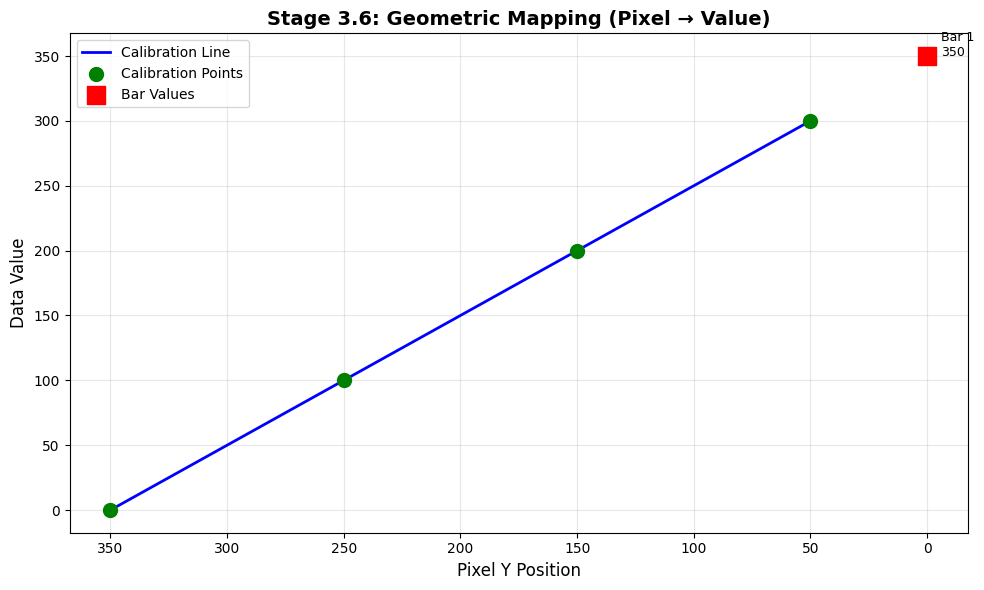

In [14]:
# Map bar heights to values
print("\nMapping Bar Heights to Values:")
print("=" * 50)

bar_values = []
for i, bar in enumerate(detection_result.bars):
    # Top of bar = the value
    pixel_y = bar.y_min  # Top of bar
    value = mapper.pixel_to_value_y(pixel_y)
    
    bar_values.append({
        'bar': i + 1,
        'pixel_y': pixel_y,
        'value': value,
        'height_px': bar.height,
    })
    
    print(f"Bar {i+1}: pixel_y={pixel_y:.0f} → value={value:.1f}")

# Visualize mapping
fig, ax = plt.subplots(figsize=(10, 6))

# Plot calibration line
pixels = np.linspace(50, 350, 100)
values = [mapper.pixel_to_value_y(p) for p in pixels]
ax.plot(pixels, values, 'b-', linewidth=2, label='Calibration Line')

# Plot calibration points
cal_pixels = [p for p, v in y_calibration]
cal_values = [v for p, v in y_calibration]
ax.scatter(cal_pixels, cal_values, c='green', s=100, zorder=5, label='Calibration Points')

# Plot mapped bar values
bar_pixels = [b['pixel_y'] for b in bar_values]
bar_vals = [b['value'] for b in bar_values]
ax.scatter(bar_pixels, bar_vals, c='red', s=150, marker='s', zorder=5, label='Bar Values')

for b in bar_values:
    ax.annotate(f"Bar {b['bar']}\n{b['value']:.0f}", 
                (b['pixel_y'], b['value']),
                textcoords="offset points", xytext=(10, 0),
                fontsize=9)

ax.set_xlabel('Pixel Y Position', fontsize=12)
ax.set_ylabel('Data Value', fontsize=12)
ax.set_title('Stage 3.6: Geometric Mapping (Pixel → Value)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_xaxis()  # Higher pixel = lower on image

plt.tight_layout()
plt.show()

---
## 8. Step 7: Chart Classification

**Mục đích:** Xác định loại chart từ các features đã extract.

**Supported Types:**
- `bar`: Bar chart (vertical/horizontal)
- `line`: Line chart
- `pie`: Pie chart
- `scatter`: Scatter plot
- `area`: Area chart

In [15]:
from core_engine.stages.s3_extraction.classifier import ChartClassifier, ClassifierConfig

# Initialize classifier
classifier_config = ClassifierConfig(
    confidence_threshold=0.5,
)
classifier = ChartClassifier(classifier_config)

# Classify based on detected elements
classification = classifier.classify(
    bars=detection_result.bars,
    polylines=vectorize_result.polylines,
    markers=detection_result.markers,
    slices=detection_result.slices,
    texts=ocr_result.texts,
)

print("Classification Result:")
print(f"  - Chart Type: {classification.chart_type.value}")
print(f"  - Confidence: {classification.confidence:.2%}")
print(f"  - Reasoning: {classification.reasoning}")

NameError: name 'vectorize_result' is not defined

NameError: name 'classification' is not defined

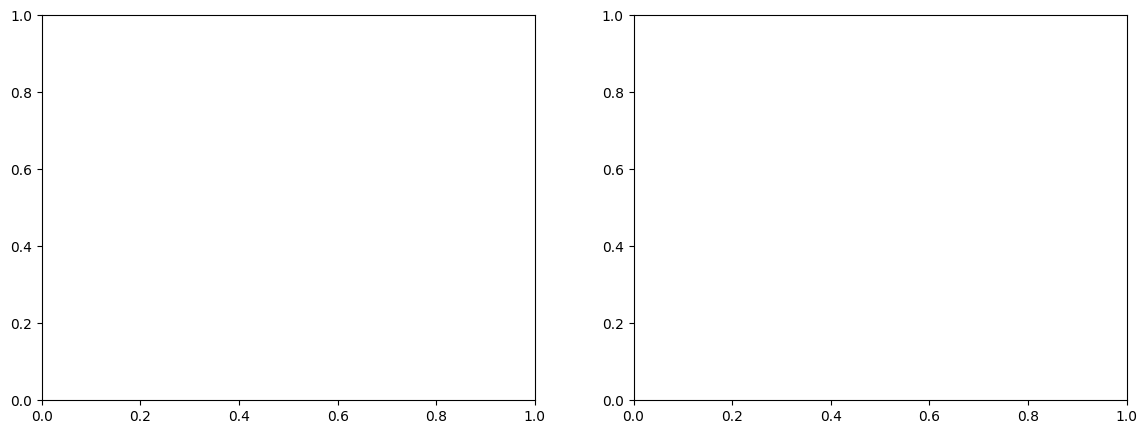

In [16]:
# Visualize classification with confidence scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original image with classification label
result_img = sample_chart.copy()
cv2.putText(result_img, 
            f"Classified as: {classification.chart_type.value.upper()}",
            (10, 395), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 128, 0), 2)

axes[0].imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Classification: {classification.chart_type.value.upper()}\nConfidence: {classification.confidence:.1%}", fontsize=12)
axes[0].axis('off')

# Feature summary
features_text = f"""
CLASSIFICATION FEATURES
{'='*40}

Detected Elements:
  - Bars: {len(detection_result.bars)}
  - Polylines: {len(vectorize_result.polylines)}
  - Markers: {len(detection_result.markers)}
  - Pie Slices: {len(detection_result.slices)}
  - Text Elements: {len(ocr_result.texts)}

Decision:
  Chart Type: {classification.chart_type.value}
  Confidence: {classification.confidence:.2%}

Reasoning:
  {classification.reasoning}
"""

axes[1].axis('off')
axes[1].text(0.05, 0.95, features_text, transform=axes[1].transAxes,
             fontsize=11, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
axes[1].set_title("Feature Analysis", fontsize=12)

plt.suptitle("Stage 3.7: Chart Classification", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Complete Pipeline: Stage3Extraction

Bây giờ chạy toàn bộ Stage 3 pipeline như một orchestrator.

In [ ]:
from datetime import datetime
from pathlib import Path
import tempfile

from core_engine.stages.s3_extraction import Stage3Extraction, ExtractionConfig
from core_engine.schemas.stage_outputs import Stage2Output, DetectedChart
from core_engine.schemas.common import SessionInfo, BoundingBox

# Save sample chart to temp file
with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as f:
    chart_path = Path(f.name)
    cv2.imwrite(str(chart_path), sample_chart)

# Create mock Stage2Output (as if from detection stage)
session = SessionInfo(
    session_id="demo_session_001",
    created_at=datetime.now(),
    source_file=Path("demo_report.pdf"),
    total_pages=1,
    config_hash="demo12345678",
)

stage2_output = Stage2Output(
    session=session,
    charts=[
        DetectedChart(
            chart_id="chart_001",
            source_image=chart_path,
            cropped_path=chart_path,
            bbox=BoundingBox(x_min=0, y_min=0, x_max=500, y_max=400, confidence=0.95),
            page_number=1,
        )
    ],
    total_detected=1,
    skipped_low_confidence=0,
)

print("Stage 2 Output (Input to Stage 3):")
print(f"  - Session ID: {session.session_id}")
print(f"  - Charts to process: {len(stage2_output.charts)}")

In [ ]:
# Run complete Stage 3 pipeline
stage3 = Stage3Extraction()  # Uses default config

print("Running Stage 3 Extraction Pipeline...")
print("=" * 50)

stage3_output = stage3.process(stage2_output)

print(f"\nStage 3 Output:")
print(f"  - Session ID: {stage3_output.session.session_id}")
print(f"  - Charts processed: {len(stage3_output.metadata)}")

In [ ]:
# Display final output
for metadata in stage3_output.metadata:
    print(f"\n{'='*60}")
    print(f"Chart ID: {metadata.chart_id}")
    print(f"{'='*60}")
    print(f"\nChart Type: {metadata.chart_type.value}")
    print(f"\nText Elements: {len(metadata.texts)}")
    for text in metadata.texts[:5]:  # Show first 5
        print(f"  - '{text.text}' (role: {text.role}, conf: {text.confidence:.2f})")
    if len(metadata.texts) > 5:
        print(f"  ... and {len(metadata.texts) - 5} more")
    
    print(f"\nChart Elements: {len(metadata.elements)}")
    for elem in metadata.elements[:5]:
        print(f"  - {elem.element_type}: bbox=({elem.bbox.x_min:.0f},{elem.bbox.y_min:.0f})-({elem.bbox.x_max:.0f},{elem.bbox.y_max:.0f})")
    if len(metadata.elements) > 5:
        print(f"  ... and {len(metadata.elements) - 5} more")

---
## 10. Summary: Stage 3 Pipeline Flow

```
┌─────────────────────────────────────────────────────────────────┐
│                     STAGE 3: EXTRACTION                         │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  Input: Stage2Output (Cropped Chart Images)                     │
│                         │                                       │
│                         ▼                                       │
│  ┌─────────────────────────────────────────┐                   │
│  │ 1. PREPROCESSING                         │                   │
│  │    • Grayscale → Denoise → Negative      │                   │
│  │    • Morphology → Adaptive Threshold     │                   │
│  └─────────────────────────────────────────┘                   │
│                         │                                       │
│           ┌─────────────┴─────────────┐                        │
│           ▼                           ▼                        │
│  ┌─────────────────┐         ┌─────────────────┐              │
│  │ 2. SKELETON     │         │ 4. OCR ENGINE   │              │
│  │    Lee's Algo   │         │    PaddleOCR    │              │
│  └─────────────────┘         └─────────────────┘              │
│           │                           │                        │
│           ▼                           │                        │
│  ┌─────────────────┐                  │                        │
│  │ 3. VECTORIZE    │                  │                        │
│  │    RDP Algo     │                  │                        │
│  └─────────────────┘                  │                        │
│           │                           │                        │
│           └─────────────┬─────────────┘                        │
│                         ▼                                       │
│  ┌─────────────────────────────────────────┐                   │
│  │ 5. ELEMENT DETECTOR                      │                   │
│  │    Bars, Markers, Pie Slices             │                   │
│  └─────────────────────────────────────────┘                   │
│                         │                                       │
│                         ▼                                       │
│  ┌─────────────────────────────────────────┐                   │
│  │ 6. GEOMETRIC MAPPER                      │                   │
│  │    Pixel → Data Value Calibration        │                   │
│  └─────────────────────────────────────────┘                   │
│                         │                                       │
│                         ▼                                       │
│  ┌─────────────────────────────────────────┐                   │
│  │ 7. CLASSIFIER                            │                   │
│  │    Chart Type Detection                  │                   │
│  └─────────────────────────────────────────┘                   │
│                         │                                       │
│                         ▼                                       │
│  Output: Stage3Output (RawMetadata)                             │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

**Key Outputs từ Stage 3:**
- `chart_type`: Loại chart (bar, line, pie, ...)
- `texts`: Tất cả text đã OCR với role classification
- `elements`: Các phần tử chart (bars, markers, slices)
- `axis_info`: Thông tin về các trục

**Next Stage:** Stage 4 sẽ sử dụng SLM để:
- Sửa lỗi OCR
- Map values chính xác hơn
- Generate mô tả academic

In [ ]:
# Cleanup
import os
if chart_path.exists():
    os.unlink(chart_path)
    
print("Notebook completed successfully!")